# **Groupby and Aggregating**

Used to group and aggregate columns

In [2]:
import numpy as np
import pandas as pd


import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
groups = df.groupby("sepal length (cm)")

# since we grouped by hence all the sepal length has been grouped together
# KEEP IN MIND, THIS WILL ONLY APPLY TO THE NUMERICAL FEATURES
print(groups.mean().shape)
groups.mean().head()

(35, 4)


,sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),,,,
4.3,3.000000,1.100000,0.100,0.0
4.4,3.033333,1.333333,0.200,0.0
4.5,2.300000,1.300000,0.300,0.0
4.6,3.325000,1.325000,0.225,0.0
4.7,3.200000,1.450000,0.200,0.0


Split (The `groupby` part)

When we did `groups = df.groupby("sepal length (cm)")`, Pandas didn't calculate anything yet. It just looked at the `sepal length (cm)` column and found all unique values (like 4.3, 4.4, 4.5, etc.). It then virtually "split" the entire dataframe into small buckets (groups).

- Bucket 1: All rows where sepal length is 4.3.
- Bucket 2: All rows where sepal length is 4.4.
- ...and so on.

Apply (The `mean()` part)

When you called `.mean()`, Pandas went into each bucket individually and calculated the average for all the numeric columns inside that bucket (sepal width, petal length, etc.).

- For the 4.4 bucket, it took the three rows it found, added their widths together, and divided by 3 to get 3.033333.

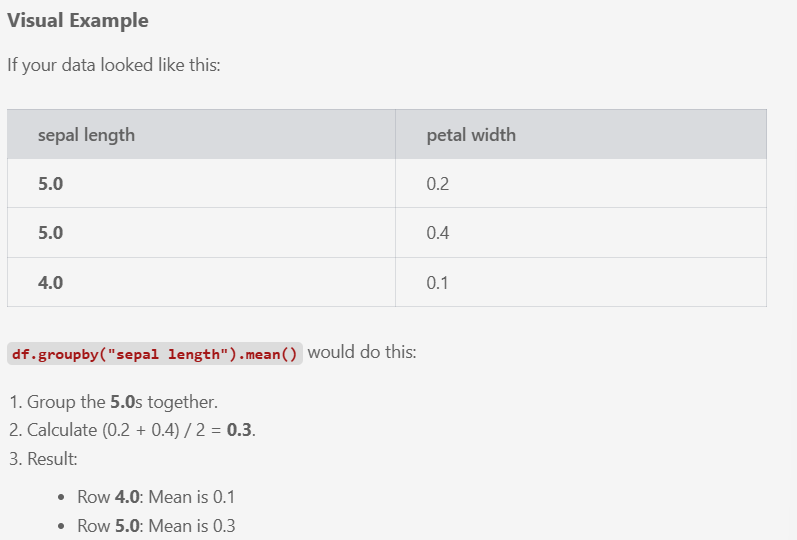

In [5]:
df.groupby("sepal length (cm)").sum().head()    
# for eg if sepal length is 4.3, then in case of sepal width it will make sum of all values at sepal width for sepal length 4.3 (THE SAME GOES FOR ALL THE FEATURES)

,sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),,,,
4.3,3.0,1.1,0.1,0
4.4,9.1,4.0,0.6,0
4.5,2.3,1.3,0.3,0
4.6,13.3,5.3,0.9,0
4.7,6.4,2.9,0.4,0


In [6]:
print(df.groupby("sepal length (cm)").mean().min().head())
print("-----------------------------------------------------------")
print(df.groupby("sepal length (cm)").mean().max().head())

sepal width (cm)     2.3
petal length (cm)    1.1
petal width (cm)     0.1
target               0.0
dtype: float64
-----------------------------------------------------------
sepal width (cm)     3.8
petal length (cm)    6.6
petal width (cm)     2.2
target               2.0
dtype: float64


### Aggregation

Keep in mind, that aggregation is just like mentioning a dictionary.


#### Parameters to use while usign aggregation

1. Central Tendency and Spread
- `'median':` Returns the middle value.
- `'std'`: Standard deviation (measure of spread).
- `'var'`: Variance.
- `'sem'`: Standard error of the mean.
- `'mad'`: Mean absolute deviation.

2. Position and Extremes
- `'first'`: The first value in the group.
- `'last'`: The last value in the group.
- `'nth'`: The n-th value (used like lambda x: x.iloc[n]).
- `'idxmin'`: The index label where the minimum value occurs.
- `'idxmax'`: The index label where the maximum value occurs.

3. Frequency and Distribution
- `'nunique'`: Count of unique values (very useful for IDs).
- `'size'`: Total number of rows including nulls (unlike count which ignores nulls).
- `'skew'`: Skewness of the distribution.
- `'kurt'`: Kurtosis (peakiness of the distribution).
- `'quantile'`: You can pass specific quantiles using a function, e.g., lambda x: x.quantile(0.75).

In [8]:
df.groupby("sepal length (cm)").agg({
    "sepal width (cm)" : "sum",
    "sepal width (cm)" : ['count', 'mean', 'sum', 'min', 'max'],    # in aggregation if you do aggregation for two features it will the feature which is mentioned last will be valid
    "petal width (cm)" : ['count', 'mean', 'sum', 'min', 'max']
})

# also one thing keep in mind that, here we are doing everything by taking sepal length as a base (doing all these functions by grouping by sepal length)



sepal width (cm)                           petal width (cm)  \
                             count      mean   sum  min  max            count   
sepal length (cm)                                                               
4.3                              1  3.000000   3.0  3.0  3.0                1   
4.4                              3  3.033333   9.1  2.9  3.2                3   
4.5                              1  2.300000   2.3  2.3  2.3                1   
4.6                              4  3.325000  13.3  3.1  3.6                4   
4.7                              2  3.200000   6.4  3.2  3.2                2   
4.8                              5  3.180000  15.9  3.0  3.4                5   
4.9                              6  2.950000  17.7  2.4  3.6                6   
5.0                             10  3.120000  31.2  2.0  3.6               10   
5.1                              9  3.477778  31.3  2.5  3.8                9   
5.2                              4  3.425000  13.7  2.7  4.1                4   
5.3                              1  3.700000   3.7  3.7  3.7                1   
5.4                              6  3.550000  21.3  3.0  3.9                6   
5.5                              7  2.842857  19.9  2.3  4.2                7   
5.6                              6  2.816667  16.9  2.5  3.0                6   
5.7                              8  3.100000  24.8  2.5  4.4                8   
5.8                              7  2.885714  20.2  2.6  4.0                7   
5.9                              3  3.066667   9.2  3.0  3.2                3   
6.0                              6  2.733333  16.4  2.2  3.4                6   
6.1                              6  2.850000  17.1  2.6  3.0                6   
6.2                              4  2.825000  11.3  2.2  3.4                4   
6.3                              9  2.855556  25.7  2.3  3.4                9   
6.4                              7  2.957143  20.7  2.7  3.2                7   
6.5                              5  3.000000  15.0  2.8  3.2                5   
6.6                              2  2.950000   5.9  2.9  3.0                2   
6.7                              8  3.050000  24.4  2.5  3.3                8   
6.8                              3  3.000000   9.0  2.8  3.2                3   
6.9                              4  3.125000  12.5  3.1  3.2                4   
7.0                              1  3.200000   3.2  3.2  3.2                1   
7.1                              1  3.000000   3.0  3.0  3.0                1   
7.2                              3  3.266667   9.8  3.0  3.6                3   
7.3                              1  2.900000   2.9  2.9  2.9                1   
7.4                              1  2.800000   2.8  2.8  2.8                1   
7.6                              1  3.000000   3.0  3.0  3.0                1   
7.7                              4  3.050000  12.2  2.6  3.8                4   
7.9                              1  3.800000   3.8  3.8  3.8                1   

                                             
                       mean   sum  min  max  
sepal length (cm)                            
4.3                0.100000   0.1  0.1  0.1  
4.4                0.200000   0.6  0.2  0.2  
4.5                0.300000   0.3  0.3  0.3  
4.6                0.225000   0.9  0.2  0.3  
4.7                0.200000   0.4  0.2  0.2  
4.8                0.200000   1.0  0.1  0.3  
4.9                0.550000   3.3  0.1  1.7  
5.0                0.430000   4.3  0.2  1.0  
5.1                0.400000   3.6  0.2  1.1  
5.2                0.475000   1.9  0.1  1.4  
5.3                0.200000   0.2  0.2  0.2  
5.4                0.516667   3.1  0.2  1.5  
5.5                0.900000   6.3  0.2  1.3  
5.6                1.416667   8.5  1.1  2.0  
5.7                1.100000   8.8  0.3  2.0  
5.8                1.400000   9.8  0.2  2.4  
5.9                1.700000   5.1  1.5  1.8  
6.0                

In [20]:
new_df = df.groupby('sepal length (cm)').agg(
    # new_col_name = (column, function)
    col1_mean = ("sepal width (cm)", "mean"),
    # col1 = ("sepal width (cm)", ["mean", 'median', 'std']),           # you cant pass multiple parameters as a list, but if you still want to do this, then you have to make a new feature for it
    col1_median = ("sepal width (cm)", "median"),
    col2_sum = ("petal length (cm)", "sum"),
    col3_count = ("petal width (cm)", "count"),
)


new_df.head(10)

,col1_mean,col1_median,col2_sum,col3_count
sepal length (cm),,,,
4.3,3.000000,3.00,1.1,1
4.4,3.033333,3.00,4.0,3
4.5,2.300000,2.30,1.3,1
4.6,3.325000,3.30,5.3,4
4.7,3.200000,3.20,2.9,2
4.8,3.180000,3.10,7.9,5
4.9,2.950000,3.05,13.6,6
5.0,3.120000,3.35,18.4,10
5.1,3.477778,3.50,15.5,9


In [26]:
new_df.groupby('sepal length (cm)').describe()

col1_mean                                              \
                      count      mean std       min       25%       50%   
sepal length (cm)                                                         
4.3                     1.0  3.000000 NaN  3.000000  3.000000  3.000000   
4.4                     1.0  3.033333 NaN  3.033333  3.033333  3.033333   
4.5                     1.0  2.300000 NaN  2.300000  2.300000  2.300000   
4.6                     1.0  3.325000 NaN  3.325000  3.325000  3.325000   
4.7                     1.0  3.200000 NaN  3.200000  3.200000  3.200000   
4.8                     1.0  3.180000 NaN  3.180000  3.180000  3.180000   
4.9                     1.0  2.950000 NaN  2.950000  2.950000  2.950000   
5.0                     1.0  3.120000 NaN  3.120000  3.120000  3.120000   
5.1                     1.0  3.477778 NaN  3.477778  3.477778  3.477778   
5.2                     1.0  3.425000 NaN  3.425000  3.425000  3.425000   
5.3                     1.0  3.700000 NaN  3.700000  3.700000  3.700000   
5.4                     1.0  3.550000 NaN  3.550000  3.550000  3.550000   
5.5                     1.0  2.842857 NaN  2.842857  2.842857  2.842857   
5.6                     1.0  2.816667 NaN  2.816667  2.816667  2.816667   
5.7                     1.0  3.100000 NaN  3.100000  3.100000  3.100000   
5.8                     1.0  2.885714 NaN  2.885714  2.885714  2.885714   
5.9                     1.0  3.066667 NaN  3.066667  3.066667  3.066667   
6.0                     1.0  2.733333 NaN  2.733333  2.733333  2.733333   
6.1                     1.0  2.850000 NaN  2.850000  2.850000  2.850000   
6.2                     1.0  2.825000 NaN  2.825000  2.825000  2.825000   
6.3                     1.0  2.855556 NaN  2.855556  2.855556  2.855556   
6.4                     1.0  2.957143 NaN  2.957143  2.957143  2.957143   
6.5                     1.0  3.000000 NaN  3.000000  3.000000  3.000000   
6.6                     1.0  2.950000 NaN  2.950000  2.950000  2.950000   
6.7                     1.0  3.050000 NaN  3.050000  3.050000  3.050000   
6.8                     1.0  3.000000 NaN  3.000000  3.000000  3.000000   
6.9                     1.0  3.125000 NaN  3.125000  3.125000  3.125000   
7.0                     1.0  3.200000 NaN  3.200000  3.200000  3.200000   
7.1                     1.0  3.000000 NaN  3.000000  3.000000  3.000000   
7.2                     1.0  3.266667 NaN  3.266667  3.266667  3.266667   
7.3                     1.0  2.900000 NaN  2.900000  2.900000  2.900000   
7.4                     1.0  2.800000 NaN  2.800000  2.800000  2.800000   
7.6                     1.0  3.000000 NaN  3.000000  3.000000  3.000000   
7.7                     1.0  3.050000 NaN  3.050000  3.050000  3.050000   
7.9                     1.0  3.800000 NaN  3.800000  3.800000  3.800000   

                                      col1_median        ... col2_sum        \
                        75%       max       count  mean  ...      75%   max   
sepal length (cm)                                        ...                  
4.3                3.000000  3.000000         1.0  3.00  ...      1.1   1.1   
4.4                3.033333  3.033333         1.0  3.00  ...      4.0   4.0   
4.5                2.300000  2.300000         1.0  2.30  ...      1.3   1.3   
4.6                3.325000  3.325000         1.0  3.30  ...      5.3   5.3   
4.7                3.200000  3.200000         1.0  3.20  ...      2.9   2.9   
4.8                3.180000  3.180000         1.0  3.10  ...      7.9   7.9   
4.9                2.950000  2.950000         1.0  3.05  ...     13.6  13.6   
5.0                3.120000  3.120000         1.0  3.35  ...     18.4  18.4   
5.1                3.477778  3.477778         1.0  3.50  ...     15.5  15.5   
5.2                3.425000  3.425000         1.0  3.45  ...      8.3   8.3   
5.3                3.700000  3.700000         1.0  3.70  ...      1.5   1.5   
5.4                3.550000  3.550000         1.0  3.55  ... 